In [1]:
import cafe

# cafe.logger.setLevel("DEBUG")

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

data

In [2]:
fadata = cafe.data.read_pancrease()
# del fadata.uns["neighbors"] # velocity neighbor info error, need recalculate
fadata

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cafe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

model selection

In [3]:
model_name_list = [
    # velocity
    "scvelo",
    "velovi",
    "dynamo",
    # "celldancer", # CBDir 和ICVCoh一直报错
    "pyrovelocity",
    "veloae",
    "unitvelo",
    # linear, pseudotime
    "comp1",
    "palantir",
    "cytotrace2",
    "sctc",
    # lineage
    "cellrank",
    # cluster
    "stavia",
    # dynverse
    "ti_slingshot",
]

benchmark caculation

In [4]:
benchmark_df = cafe.benchmark.benchmark_metrics(fadata, model_name_list, overall_score_func=True, if_save=True)
benchmark_df

INFO     |- metric file for model 'scvelo' already exists. read it.                                                                                                                                     
INFO     |- metric file for model 'velovi' already exists. read it.                                                                                                                                     
INFO     |- metric file for model 'dynamo' already exists. read it.                                                                                                                                     
INFO     |- metric file for model 'pyrovelocity' already exists. read it.                                                                                                                               


INFO     |- metric file for model 'veloae' already exists. read it.                                                                                                                                     
INFO     |- metric file for model 'unitvelo' already exists. read it.                                                                                                                                   
INFO     |- metric file for model 'comp1' already exists. read it.                                                                                                                                      
INFO     |- model comp1 missing metrics: ['correlation'], recalculating...                                                                                                                              
WARNING  |- metric 'correlation' calculation failed for trajectory 'ref(ref)' vs 'comp1(pred)'                                                                                                      

,pseudotime_correlation,velocity_cbdir,velocity_icvcoh,isomorphic,edge_flip,him,correlation,F1_branches,F1_milestones,rf_mse,...,featureimp_ks,featureimp_wilcox,harm_mean,geom_mean,arith_mean,time,time_text,memory,memory_text,overall
scvelo,0.995491,0.769390,0.893927,1.0,1.000000,0.961104,0.882257,1.000000,1.000000,0.999998,...,0.990982,0.990982,0.990982,0.990982,0.990982,14.000000,14s,920.62,921M,0.926272
velovi,0.995491,0.779817,0.920762,1.0,1.000000,0.961104,0.882257,1.000000,1.000000,0.999998,...,0.990982,0.990982,0.990982,0.990982,0.990982,331.190000,6min,2329.13,2G,0.929395
dynamo,0.538110,0.764381,0.885697,0.0,0.500000,0.560073,0.778714,0.775247,0.940568,0.988796,...,0.076220,0.076220,0.076220,0.076220,0.076220,125.330000,2min,5503.20,5G,0.650080
pyrovelocity,0.914959,0.571753,0.784076,0.0,0.750000,0.527937,0.838167,0.801445,0.944028,0.997968,...,0.829917,0.829917,0.829917,0.829917,0.829917,672.870000,11min,14051.57,14G,0.685909
veloae,0.483914,0.409837,0.917911,0.0,0.500000,0.573619,0.789336,0.923097,0.931739,0.996848,...,-0.032172,-0.032172,-0.032172,-0.032172,-0.032172,37.120000,37s,2283.07,2G,0.569262
unitvelo,0.845977,0.745192,0.952016,0.0,0.500000,0.341345,0.799183,0.714663,0.920024,0.995023,...,0.691954,0.691954,0.691954,0.691954,0.691954,482.830000,8min,3624.93,4G,0.626225
comp1,0.950242,0.677917,0.999886,0.0,0.000000,0.267002,0.500000,0.189011,0.281500,0.851693,...,0.531060,0.531060,0.281500,0.281500,0.281500,0.000000,0s,0.00,0M,0.424623
palantir,0.990816,0.687106,0.999898,0.0,0.000000,0.267002,0.674271,0.189011,0.271796,0.890567,...,0.981632,0.981632,0.981632,0.981632,0.981632,0.000000,0s,0.00,0M,0.430531
cytotrace2,0.870004,0.655362,0.999847,0.0,0.000000,0.267002,0.096048,0.189011,0.282081,0.757478,...,0.740008,0.740008,0.740008,0.740008,0.740008,0.000000,0s,0.00,0M,0.411861
sctc,0.484805,0.321551,0.999859,0.0,0.000000,0.267002,0.000000,0.189011,0.284392,0.820167,...,-0.030390,-0.030390,-0.030390,-0.030390,-0.030390,0.000000,0s,0.00,0M,0.297821


benchmark visualization

No legends were provided, trying to automatically infer legends.
Some palettes were not used in the column info, adding legends for them:palette2, white6black4, palette1, palette3
Legend {'title': 'palette2', 'palette': 'palette2', 'enabled': True} did not contain a geom, inferring from the column_info.
Legend {'title': 'palette2', 'palette': 'palette2', 'enabled': True, 'geom': 'rect'} did not contain labels, inferring from the geom.
Legend {'title': 'palette2', 'palette': 'palette2', 'enabled': True, 'geom': 'rect', 'labels': ['0', '', '0.2', '', '0.4', '', '0.6', '', '0.8', '', '1']} did not contain size, inferring from the labels.
Legend {'title': 'palette2', 'palette': 'palette2', 'enabled': True, 'geom': 'rect', 'labels': ['0', '', '0.2', '', '0.4', '', '0.6', '', '0.8', '', '1'], 'size': [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]} did not contain color, inferring from the palette.
Legend {'title': 'white6black4', 'palett

<Figure size 3200x2400 with 0 Axes>

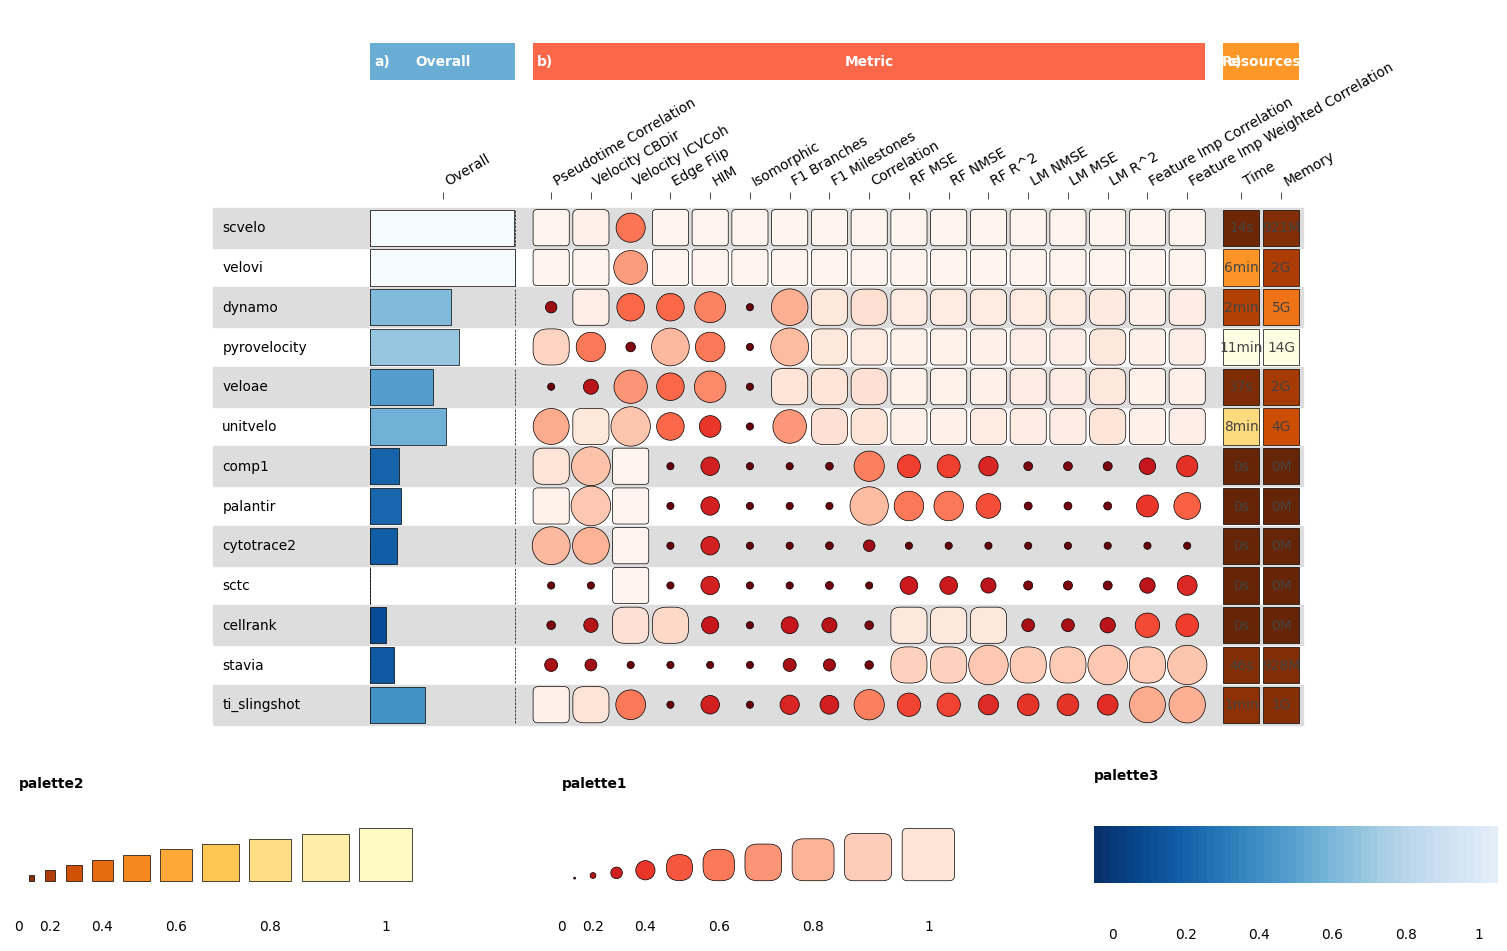

In [5]:
cafe.benchmark.benchmark_visualization(benchmark_df)